 Application de l'EDA sur le Dataset Credit Card Fraud Detection

In [1]:
# @title 1. Initialisation et configuration
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configuration des visualisations
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 8)

In [ ]:
# @title 2. CHARGEMENT ET STRUCTURE DES DONNÉES
try:
    !kaggle datasets download -d mlg-ulb/creditcardfraud -p /content/
    !unzip -o /content/creditcardfraud.zip -d /content/
    df = pd.read_csv('/content/creditcard.csv')
except:
    print("Kaggle non configuré. Veuillez uploader le fichier creditcard.csv")
    uploaded = files.upload()
    filename = list(uploaded.keys())[0]
    df = pd.read_csv(io.BytesIO(uploaded[filename]))
df = pd.read_csv('creditcard.csv')
print(f"\nDimensions: {df.shape}")
print(f"\nColonnes:\n{df.columns.tolist()}")
print(f"\nTypes de données:\n{df.dtypes}")

# Aperçu
print("\nPremières lignes:")
print(df.head())

Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
creditcardfraud.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  /content/creditcardfraud.zip
  inflating: /content/creditcard.csv  

Dimensions: (284807, 31)

Colonnes:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Types de données:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25     

In [ ]:
# @title 3. CONTRÔLE QUALITÉ
# Valeurs manquantes
print(f"\nValeurs manquantes: {df.isnull().sum().sum()}")

# Doublons
duplicates = df.duplicated().sum()
print(f"Doublons: {duplicates} ({duplicates/len(df)*100:.4f}%)")

# Variables d'identité (Time et Amount)
print("\nStatistiques descriptives (Time & Amount):")
print(df[['Time', 'Amount']].describe())


Valeurs manquantes: 0
Doublons: 1081 (0.3796%)

Statistiques descriptives (Time & Amount):
                Time         Amount
count  284807.000000  284807.000000
mean    94813.859575      88.349619
std     47488.145955     250.120109
min         0.000000       0.000000
25%     54201.500000       5.600000
50%     84692.000000      22.000000
75%    139320.500000      77.165000
max    172792.000000   25691.160000


Transactions normales (0): 284,315 (99.8273%)
Fraudes (1): 492 (0.1727%)
Ratio déséquilibre: 577.88:1


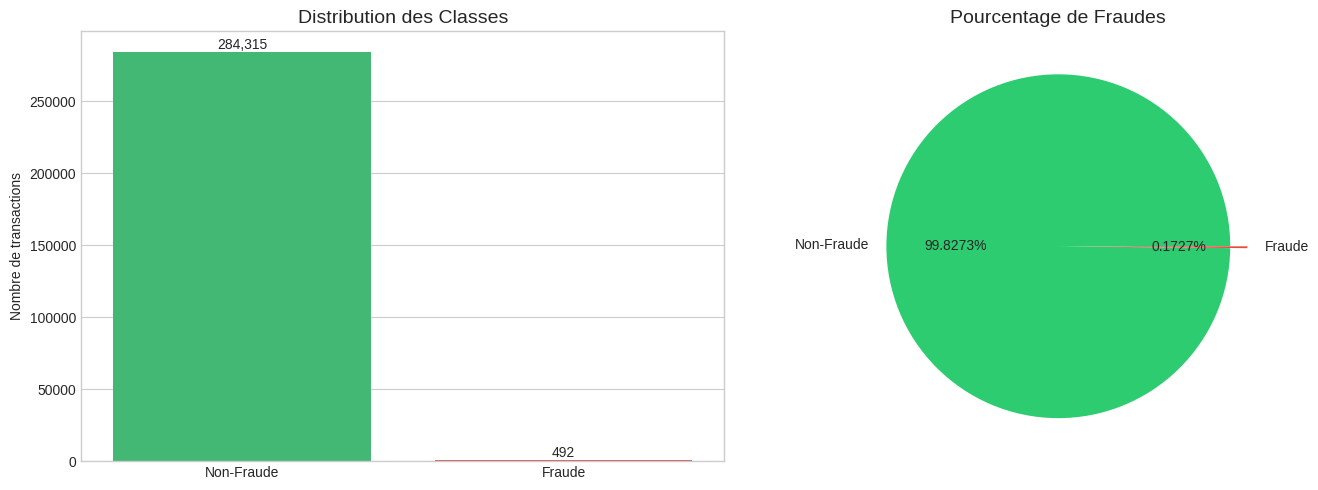

In [ ]:
# @title 4. ANALYSE DU DÉSÉQUILIBRE (PROBLÉMATIQUE CLÉ)
class_counts = df['Class'].value_counts()
class_percent = df['Class'].value_counts(normalize=True) * 100

print(f"Transactions normales (0): {class_counts[0]:,} ({class_percent[0]:.4f}%)")
print(f"Fraudes (1): {class_counts[1]:,} ({class_percent[1]:.4f}%)")
print(f"Ratio déséquilibre: {class_counts[0]/class_counts[1]:.2f}:1")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barplot
sns.barplot(x=['Non-Fraude', 'Fraude'], y=class_counts, ax=axes[0], palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Distribution des Classes', fontsize=14)
axes[0].set_ylabel('Nombre de transactions')
axes[0].text(0, class_counts[0], f'{class_counts[0]:,}', ha='center', va='bottom')
axes[0].text(1, class_counts[1], f'{class_counts[1]:,}', ha='center', va='bottom')

# Pie chart
axes[1].pie(class_counts, labels=['Non-Fraude', 'Fraude'], autopct='%1.4f%%',
            colors=['#2ecc71', '#e74c3c'], explode=(0, 0.1))
axes[1].set_title('Pourcentage de Fraudes', fontsize=14)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

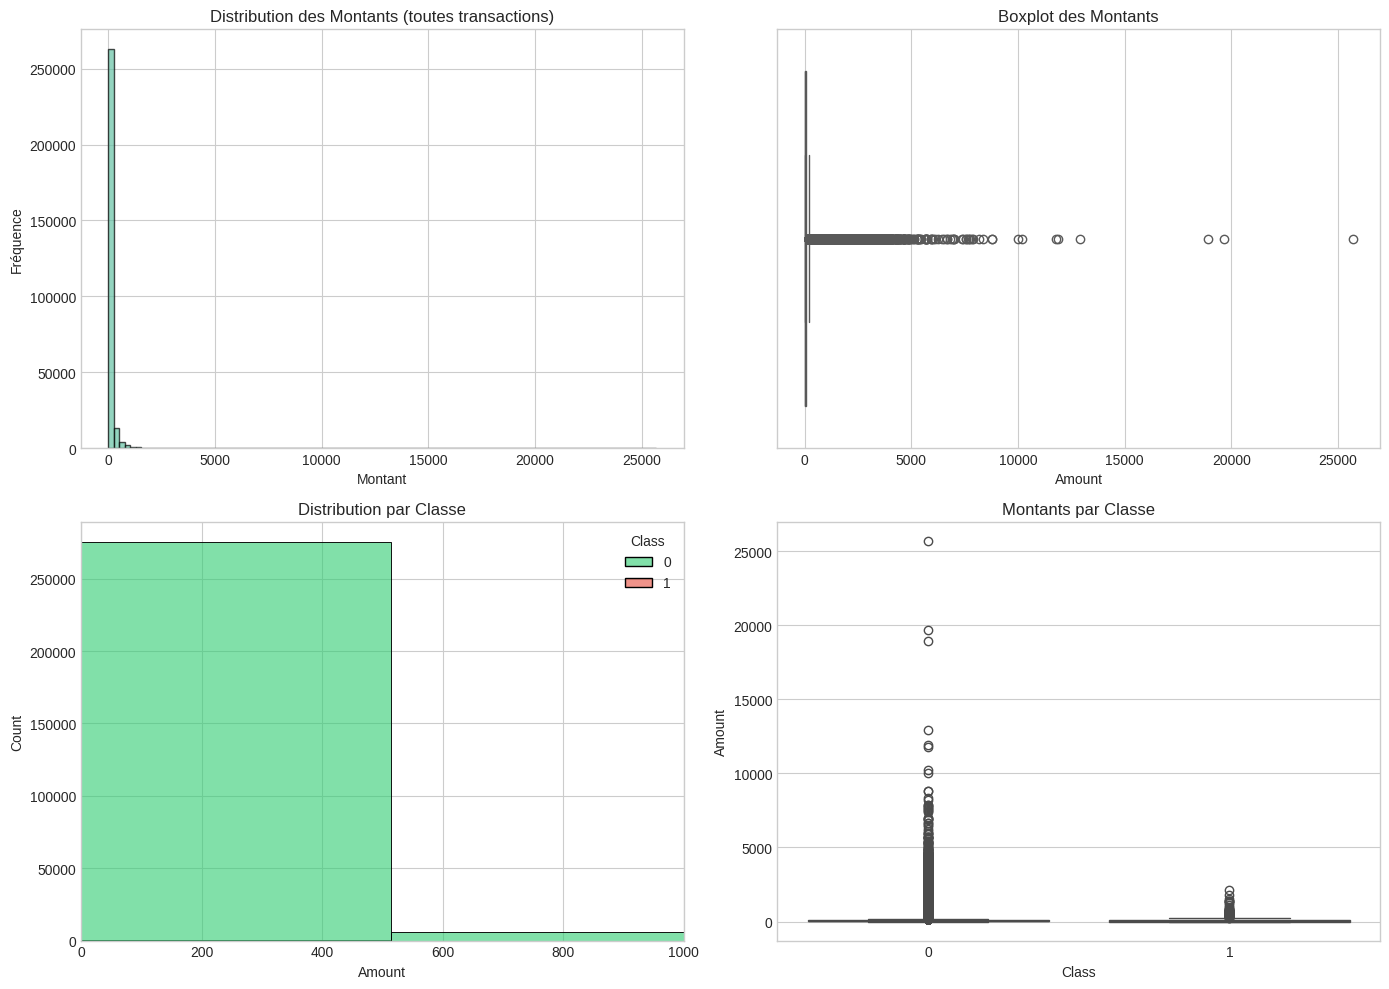


Statistiques des montants par classe:
          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      284315.0   88.291022  250.105092  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.211321  256.683288  0.0  1.00   9.25  105.89   2125.87


In [ ]:
# @title 5. ANALYSE UNIVARIÉE - AMOUNT(MONTANT DES TRANSACTIONS)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distribution globale
axes[0, 0].hist(df['Amount'], bins=100, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribution des Montants (toutes transactions)', fontsize=12)
axes[0, 0].set_xlabel('Montant')
axes[0, 0].set_ylabel('Fréquence')

# Boxplot
sns.boxplot(x=df['Amount'], ax=axes[0, 1])
axes[0, 1].set_title('Boxplot des Montants', fontsize=12)

# Distribution par classe
sns.histplot(data=df, x='Amount', hue='Class', bins=50,
             ax=axes[1, 0], palette=['#2ecc71', '#e74c3c'], alpha=0.6)
axes[1, 0].set_title('Distribution par Classe', fontsize=12)
axes[1, 0].set_xlim(0, 1000)

# Boxplot par classe
sns.boxplot(x='Class', y='Amount', data=df, ax=axes[1, 1],
            palette=['#2ecc71', '#e74c3c'])
axes[1, 1].set_title('Montants par Classe', fontsize=12)

plt.tight_layout()
plt.savefig('amount_analysis.png', dpi=150)
plt.show()

# Statistiques
print("\nStatistiques des montants par classe:")
print(df.groupby('Class')['Amount'].describe())

# Test statistique
from scipy.stats import mannwhitneyu
stat, p_value = mannwhitneyu(df[df['Class']==0]['Amount'],
                              df[df['Class']==1]['Amount'])

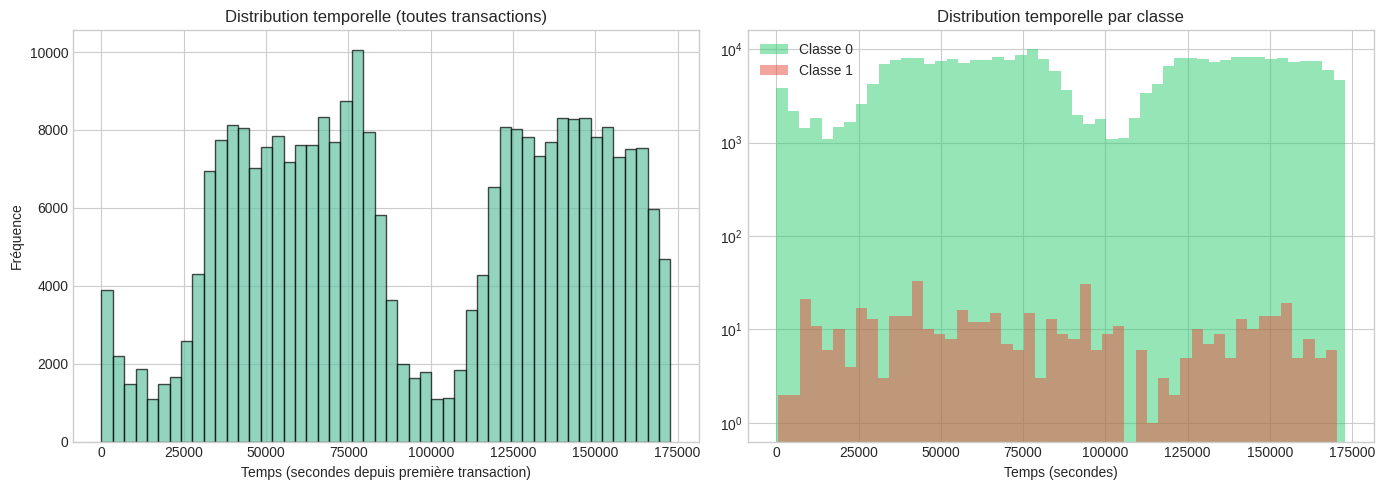

In [ ]:
# @title 6. ANALYSE TEMPORELLE
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution temporelle globale
axes[0].hist(df['Time'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution temporelle (toutes transactions)', fontsize=12)
axes[0].set_xlabel('Temps (secondes depuis première transaction)')
axes[0].set_ylabel('Fréquence')

# Distribution par classe
for label, color in [(0, '#2ecc71'), (1, '#e74c3c')]:
    subset = df[df['Class'] == label]['Time']
    axes[1].hist(subset, bins=50, alpha=0.5, label=f'Classe {label}', color=color)
axes[1].set_title('Distribution temporelle par classe', fontsize=12)
axes[1].set_xlabel('Temps (secondes)')
axes[1].legend()
axes[1].set_yscale('log')

plt.tight_layout()
plt.savefig('time_analysis.png', dpi=150)
plt.show()